# Multi-topic MATH: GRPO and correct-to-wrong constraint
Run prepare_math_data.py, train.py, evaluate.py, compare.py first. The original plots use the full held-out test. Additional plots at the end use only questions that were **not capped for any method**. The same questions are compared across methods, and the number retained is shown. This selected subset is diagnostic, not a replacement for full-test accuracy.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd()
if not (root / 'configs' / 'general_math_baseline.json').exists():
    root = root / 'pact_grpo_math'
config_name = 'general_math_baseline.json'
config = json.loads((root / 'configs' / config_name).read_text(encoding='utf-8'))
output = root / 'outputs' / config['run_name']
results = pd.read_csv(output / 'comparison.csv')
display(results)
methods = ['initial', 'grpo', 'grpo_reference_kl', 'cokl_grpo', 'flip_constrained_grpo']
labels = ['Initial', 'GRPO', 'GRPO + KL', 'CoKL-GRPO', 'Flip constraint']
filtered_rows = []
cohort_rows = []
for seed in config['training_seeds']:
    predictions = {}
    for method in methods:
        path = output / f'seed_{seed}' / method / 'evaluation.json'
        if not path.exists():
            raise FileNotFoundError(f'Missing {path}; finish evaluate.py for every method first')
        evaluation = json.loads(path.read_text(encoding='utf-8'))
        predictions[method] = {item['uid']: item for item in evaluation['test']['predictions']}
    ids = set(predictions['initial'])
    if any(set(predictions[m]) != ids for m in methods):
        raise ValueError(f'Seed {seed}: test question IDs differ across methods')
    shared = {uid for uid in ids if all(not predictions[m][uid]['capped'] for m in methods)}
    if not shared:
        print(f'Seed {seed}: no shared uncapped test questions; full-test plots remain valid')
    before = predictions['initial']
    cohort_rows.append({'seed': seed, 'full_test_n': len(ids), 'shared_uncapped_n': len(shared),
                        'excluded_n': len(ids) - len(shared),
                        'initially_correct_shared_n': sum(before[uid]['correct'] for uid in shared)})
    for method in methods:
        after = predictions[method]
        row = {'seed': seed, 'method': method, 'shared_n': len(shared),
               'accuracy': (np.mean([after[uid]['correct'] for uid in shared]) if shared else np.nan),
               'correct_to_wrong': sum(before[uid]['correct'] and not after[uid]['correct'] for uid in shared),
               'wrong_to_correct': sum(not before[uid]['correct'] and after[uid]['correct'] for uid in shared)}
        topic_accuracies = []
        for topic in config['topics']:
            topic_ids = [uid for uid in shared if before[uid]['topic'] == topic]
            originally_correct = sum(before[uid]['correct'] for uid in topic_ids)
            row[f'n_{topic}'] = len(topic_ids)
            row[f'initially_correct_{topic}'] = originally_correct
            row[f'accuracy_{topic}'] = (np.mean([after[uid]['correct'] for uid in topic_ids])
                                         if topic_ids else np.nan)
            row[f'flip_rate_{topic}'] = (sum(before[uid]['correct'] and not after[uid]['correct']
                                            for uid in topic_ids) / originally_correct
                                        if originally_correct else np.nan)
            topic_accuracies.append(row[f'accuracy_{topic}'])
        row['worst_topic_accuracy'] = (np.nanmin(topic_accuracies) if shared else np.nan)
        filtered_rows.append(row)
filtered = pd.DataFrame(filtered_rows)
cohorts = pd.DataFrame(cohort_rows)
display(cohorts)
display(filtered[['seed', 'method', 'shared_n', 'accuracy', 'correct_to_wrong', 'wrong_to_correct']])

,seed,method,test_macro_accuracy,test_worst_topic_accuracy,validation_macro_accuracy,test_capped_rate,test_no_box_rate,validation_capped_rate,correct_to_wrong,initially_correct_test,...,test_flip_rate_geometry,initially_correct_test_geometry,test_number_theory,validation_number_theory,test_flip_rate_number_theory,initially_correct_test_number_theory,test_counting_and_probability,validation_counting_and_probability,test_flip_rate_counting_and_probability,initially_correct_test_counting_and_probability
0,42,initial,0.29375,0.150,0.3250,0.02500,0.06875,0.0375,0,47,...,0.000000,12,0.150,0.30,0.000000,6,0.225,0.35,0.000000,9
1,42,grpo,0.30625,0.200,0.3000,0.01250,0.04375,0.0375,10,47,...,0.333333,12,0.200,0.35,0.333333,6,0.250,0.30,0.222222,9
2,42,grpo_reference_kl,0.26875,0.125,0.3125,0.00625,0.04375,0.0125,11,47,...,0.416667,12,0.125,0.40,0.333333,6,0.300,0.30,0.111111,9
3,42,cokl_grpo,0.28125,0.150,0.3125,0.01875,0.04375,0.0625,10,47,...,0.333333,12,0.150,0.20,0.333333,6,0.225,0.30,0.111111,9
4,42,flip_constrained_grpo,0.31250,0.200,0.3000,0.01250,0.05000,0.0625,7,47,...,0.333333,12,0.200,0.30,0.166667,6,0.250,0.35,0.111111,9


,seed,full_test_n,shared_uncapped_n,excluded_n,initially_correct_shared_n
0,42,160,151,9,46


,seed,method,shared_n,accuracy,correct_to_wrong,wrong_to_correct
0,42,initial,151,0.304636,0,0
1,42,grpo,151,0.311258,9,10
2,42,grpo_reference_kl,151,0.284768,10,7
3,42,cokl_grpo,151,0.298013,9,8
4,42,flip_constrained_grpo,151,0.331126,6,10


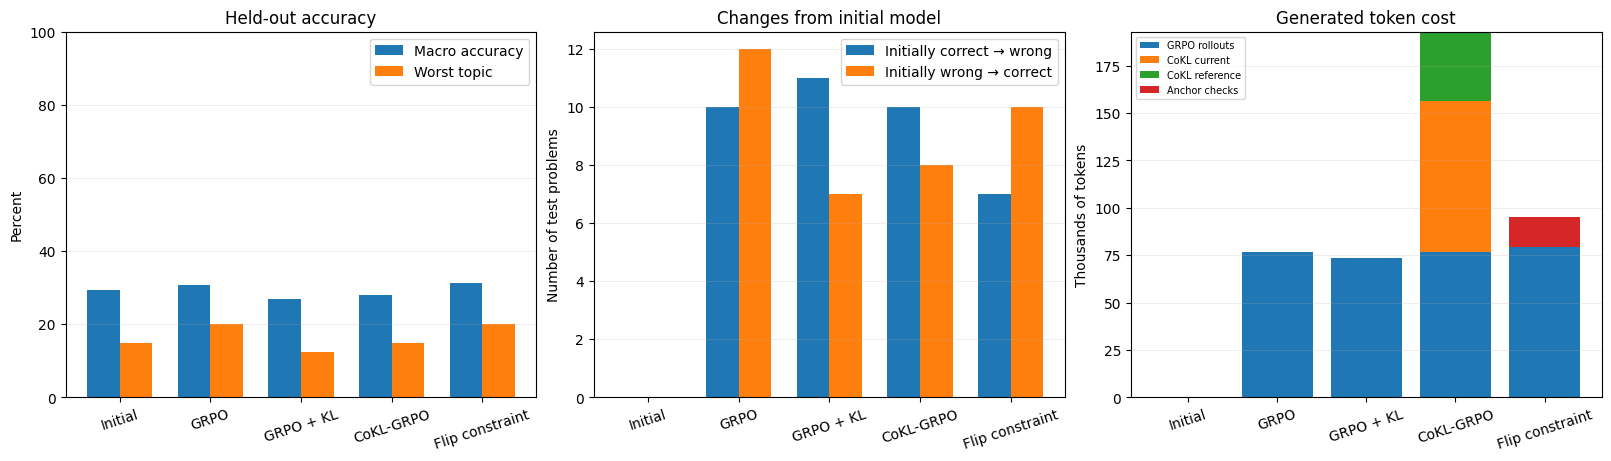

In [2]:
methods = ['initial', 'grpo', 'grpo_reference_kl', 'cokl_grpo', 'flip_constrained_grpo']
labels = ['Initial', 'GRPO', 'GRPO + KL', 'CoKL-GRPO', 'Flip constraint']
means = results.groupby('method').mean(numeric_only=True).reindex(methods)
x = np.arange(len(methods))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].bar(x-.18, means.test_macro_accuracy*100, .36, label='Macro accuracy')
axes[0].bar(x+.18, means.test_worst_topic_accuracy*100, .36, label='Worst topic')
axes[0].set(title='Held-out accuracy', ylabel='Percent', ylim=(0,100))
axes[0].legend()
axes[1].bar(x-.18, means.correct_to_wrong, .36, label='Initially correct → wrong')
axes[1].bar(x+.18, means.wrong_to_correct, .36, label='Initially wrong → correct')
axes[1].set(title='Changes from initial model', ylabel='Number of test problems')
axes[1].legend()
axes[2].bar(x, means.rollout_tokens/1000, label='GRPO rollouts')
axes[2].bar(x, means.cokl_generated_tokens/1000, bottom=means.rollout_tokens/1000, label='CoKL current')
axes[2].bar(x, means.cokl_reference_buffer_tokens/1000, bottom=(means.rollout_tokens+means.cokl_generated_tokens)/1000, label='CoKL reference')
axes[2].bar(x, means.retention_eval_tokens/1000, bottom=(means.rollout_tokens+means.cokl_generated_tokens+means.cokl_reference_buffer_tokens)/1000, label='Anchor checks')
axes[2].set(title='Generated token cost', ylabel='Thousands of tokens')
axes[2].legend(fontsize=7)
for ax in axes:
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
plt.show()

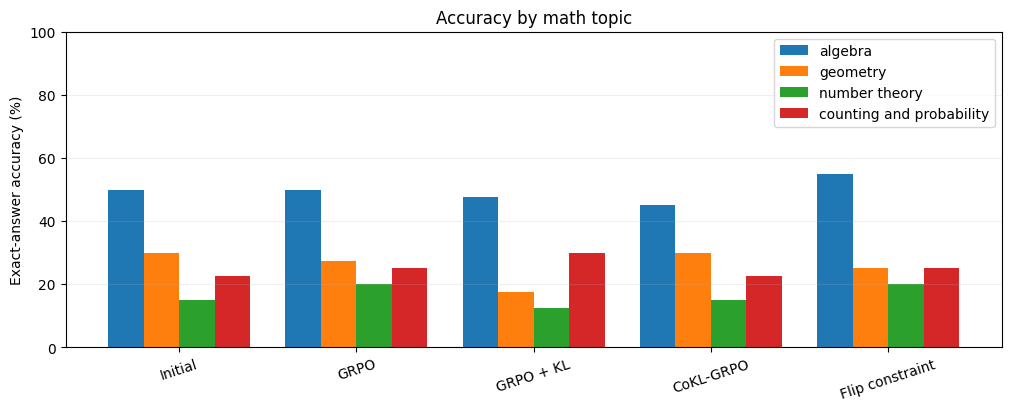

,rollout_tokens,cokl_generated_tokens,cokl_reference_buffer_tokens,retention_eval_tokens,train_seconds,mixed_group_rate,retention_checks,retention_flip_rate_train,retention_active_updates
method,,,,,,,,,
initial,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.000,0.0
grpo,76852.0,0.0,0.0,0.0,4482.987,0.453,0.0,0.000,0.0
grpo_reference_kl,73688.0,0.0,0.0,0.0,4898.076,0.375,0.0,0.000,0.0
cokl_grpo,76497.0,80017.0,36453.0,0.0,26038.209,0.422,0.0,0.000,0.0
flip_constrained_grpo,79425.0,0.0,0.0,15746.0,8719.566,0.422,64.0,0.375,64.0


In [3]:
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
width = .8 / len(config['topics'])
for i, topic in enumerate(config['topics']):
    ax.bar(x-.4+(i+.5)*width, means[f'test_{topic}']*100, width, label=topic.replace('_',' '))
ax.set(title='Accuracy by math topic', ylabel='Exact-answer accuracy (%)', ylim=(0,100))
ax.set_xticks(x, labels, rotation=18)
ax.legend()
ax.grid(axis='y', alpha=.2)
plt.show()
display(means[['rollout_tokens','cokl_generated_tokens','cokl_reference_buffer_tokens','retention_eval_tokens','train_seconds','mixed_group_rate','retention_checks','retention_flip_rate_train','retention_active_updates']].round(3))

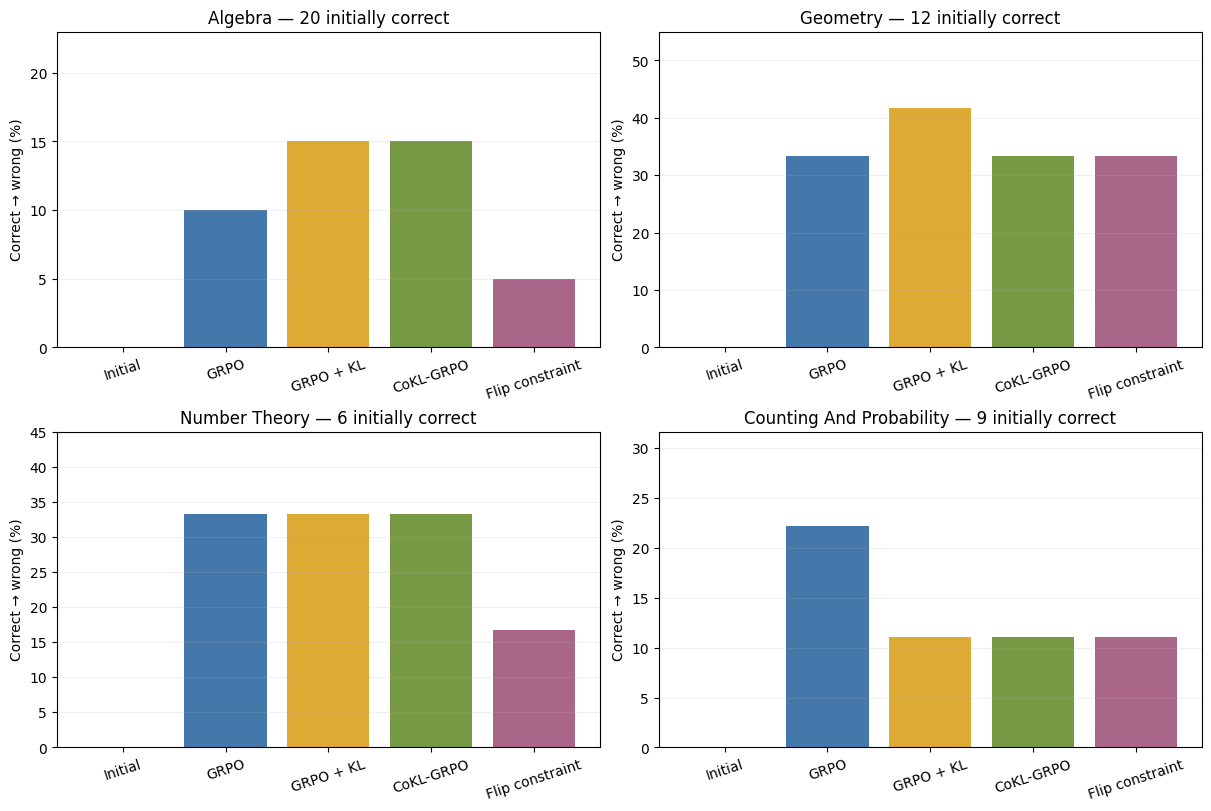

,initially_correct,initial,grpo,grpo_reference_kl,cokl_grpo,flip_constrained_grpo
topic,,,,,,
algebra,20.0,0.0,0.100,0.150,0.150,0.050
geometry,12.0,0.0,0.333,0.417,0.333,0.333
number_theory,6.0,0.0,0.333,0.333,0.333,0.167
counting_and_probability,9.0,0.0,0.222,0.111,0.111,0.111


In [4]:
# Held-out correct-to-wrong rate is conditional on the initial model being correct.
# Each panel shows its denominator so small-topic percentages are not mistaken for strong evidence.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
flip_rows = []
for ax, topic in zip(axes.flat, config['topics']):
    original_correct = means.loc['initial', f'initially_correct_test_{topic}']
    rates = means[f'test_flip_rate_{topic}'] * 100
    if original_correct > 0:
        ax.bar(x, rates, color=['#8090a6', '#4477aa', '#ddaa33', '#779944', '#aa6688'])
        ax.set_ylim(0, max(10, min(100, rates.max() * 1.2 + 5)))
    else:
        ax.text(.5, .5, 'No initially correct test cases', ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 100)
    ax.set(title=f"{topic.replace('_', ' ').title()} — {int(original_correct)} initially correct", ylabel='Correct → wrong (%)')
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
    flip_rows.append({'topic': topic, 'initially_correct': original_correct, **{m: (means.loc[m, f'test_flip_rate_{topic}'] if original_correct else np.nan) for m in methods}})
plt.show()
display(pd.DataFrame(flip_rows).set_index('topic').round(3))

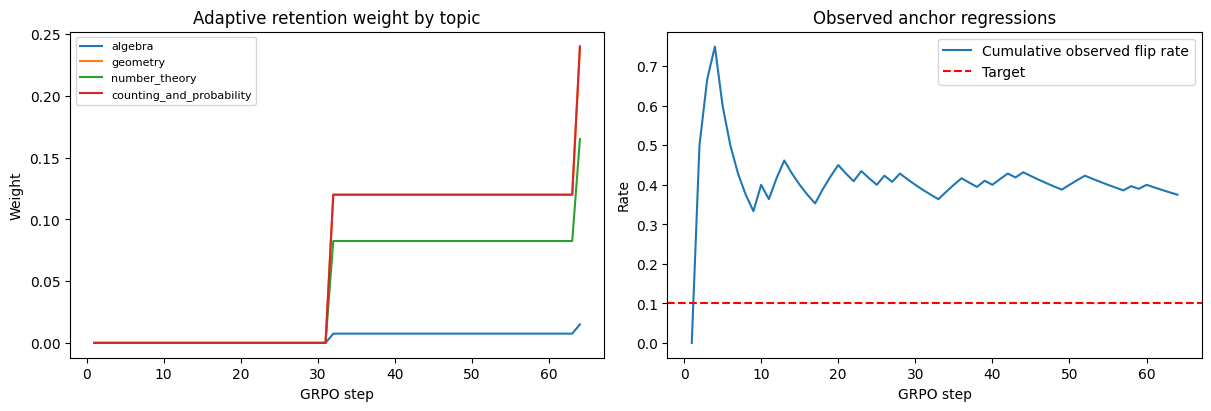

In [5]:
folder = output / f"seed_{config['training_seeds'][0]}" / 'flip_constrained_grpo'
metrics = pd.read_json(folder / 'train_metrics.jsonl', lines=True)
topics = config['topics']
fig, axes = plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for topic in topics:
    axes[0].plot(metrics.step, metrics.retention_multipliers.map(lambda d: d[topic]), label=topic)
axes[0].set(title='Adaptive retention weight by topic', xlabel='GRPO step', ylabel='Weight')
axes[0].legend(fontsize=8)
axes[1].plot(metrics.step, metrics.retention_flips / metrics.retention_checks.replace(0,np.nan), label='Cumulative observed flip rate')
axes[1].axhline(config['target_flip_rate'],color='red',linestyle='--',label='Target')
axes[1].set(title='Observed anchor regressions',xlabel='GRPO step',ylabel='Rate')
axes[1].legend()
plt.show()

## Diagnostic: questions completed by every method
A test question is included below only when **initial and all four trained methods are uncapped**. This keeps the question set identical across methods. Excluding questions based on the models' outputs introduces selection bias, so use these charts to diagnose truncation, not as the main performance claim.

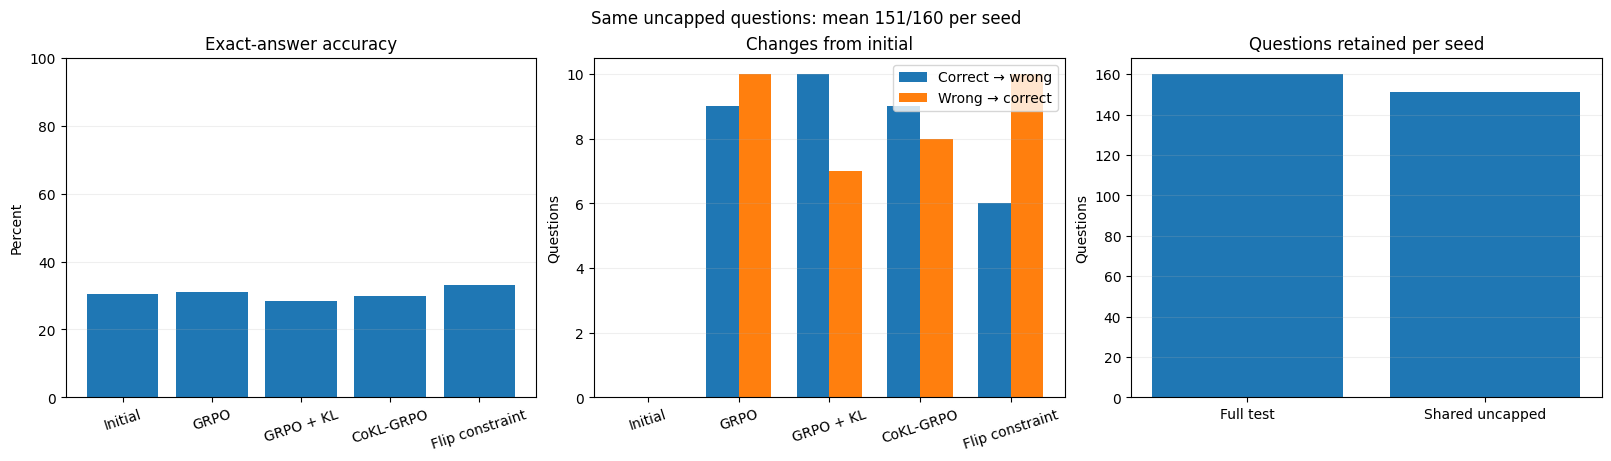

,seed,method,shared_n,accuracy,correct_to_wrong,wrong_to_correct
0,42,initial,151,0.305,0,0
1,42,grpo,151,0.311,9,10
2,42,grpo_reference_kl,151,0.285,10,7
3,42,cokl_grpo,151,0.298,9,8
4,42,flip_constrained_grpo,151,0.331,6,10


In [6]:
filtered_means = filtered.groupby('method').mean(numeric_only=True).reindex(methods)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].bar(x, filtered_means.accuracy * 100)
axes[0].set(title='Exact-answer accuracy', ylabel='Percent', ylim=(0, 100))
axes[1].bar(x-.18, filtered_means.correct_to_wrong, .36, label='Correct → wrong')
axes[1].bar(x+.18, filtered_means.wrong_to_correct, .36, label='Wrong → correct')
axes[1].set(title='Changes from initial', ylabel='Questions')
axes[1].legend()
axes[2].bar(['Full test', 'Shared uncapped'],
            [cohorts.full_test_n.mean(), cohorts.shared_uncapped_n.mean()])
axes[2].set(title='Questions retained per seed', ylabel='Questions')
for ax in axes[:2]:
    ax.set_xticks(x, labels, rotation=18)
for ax in axes:
    ax.grid(axis='y', alpha=.2)
fig.suptitle(f"Same uncapped questions: mean {cohorts.shared_uncapped_n.mean():.0f}/{cohorts.full_test_n.mean():.0f} per seed")
plt.show()
display(filtered[['seed', 'method', 'shared_n', 'accuracy', 'correct_to_wrong', 'wrong_to_correct']].round(3))

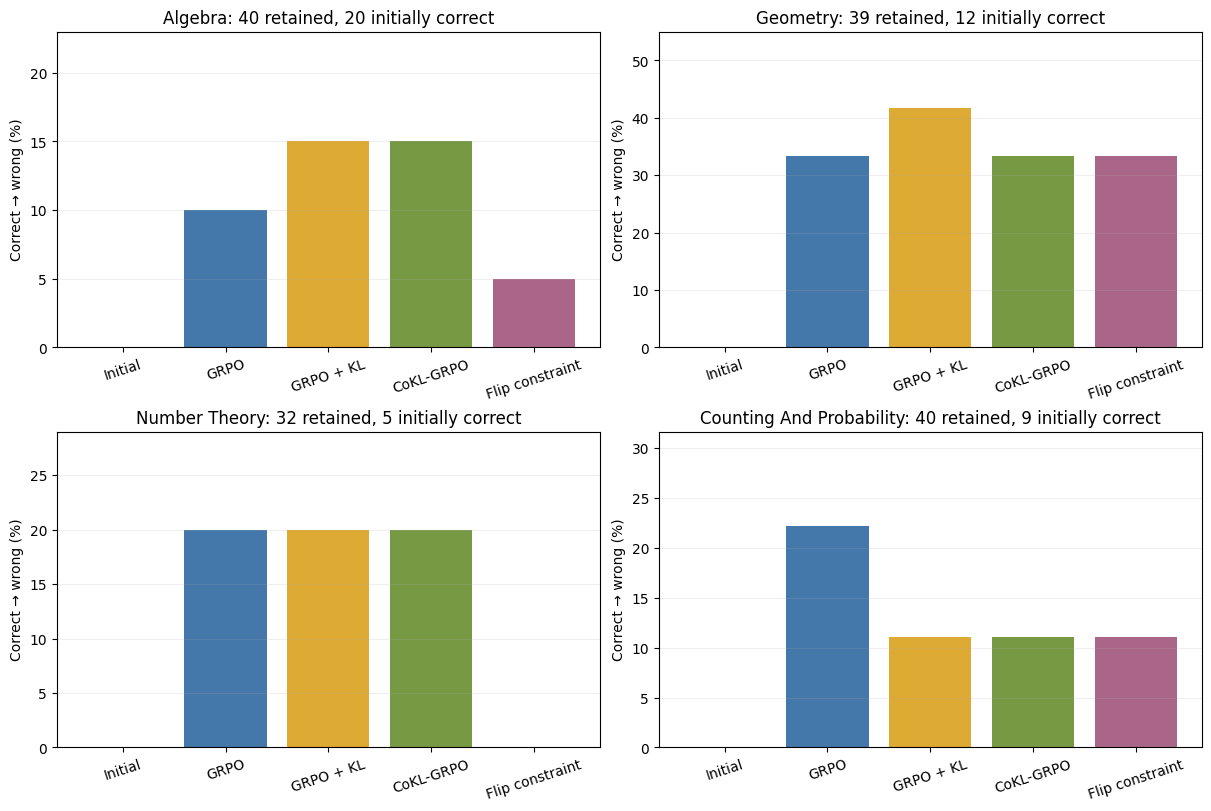

,retained_n,initially_correct_n,initial,grpo,grpo_reference_kl,cokl_grpo,flip_constrained_grpo
topic,,,,,,,
algebra,40.0,20.0,0.0,0.100,0.150,0.150,0.050
geometry,39.0,12.0,0.0,0.333,0.417,0.333,0.333
number_theory,32.0,5.0,0.0,0.200,0.200,0.200,0.000
counting_and_probability,40.0,9.0,0.0,0.222,0.111,0.111,0.111


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
uncapped_topic_rows = []
for ax, topic in zip(axes.flat, config['topics']):
    n = filtered_means.loc['initial', f'n_{topic}']
    initially_correct = filtered_means.loc['initial', f'initially_correct_{topic}']
    rates = filtered_means[f'flip_rate_{topic}'] * 100
    if initially_correct:
        ax.bar(x, rates.fillna(0), color=['#8090a6', '#4477aa', '#ddaa33', '#779944', '#aa6688'])
        ax.set_ylim(0, max(10, min(100, rates.max() * 1.2 + 5)))
    else:
        ax.text(.5, .5, 'No initially correct questions', ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 100)
    ax.set(title=f"{topic.replace('_', ' ').title()}: {n:.0f} retained, {initially_correct:.0f} initially correct",
           ylabel='Correct → wrong (%)')
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
    uncapped_topic_rows.append({'topic': topic, 'retained_n': n,
                                'initially_correct_n': initially_correct,
                                **{m: filtered_means.loc[m, f'flip_rate_{topic}'] for m in methods}})
plt.show()
display(pd.DataFrame(uncapped_topic_rows).set_index('topic').round(3))

## Ba seed: kết quả chính

Cùng 160 bài test và 47 bài model gốc giải đúng. Hiển thị cả seed 43 vì đây là một lần chạy hợp lệ, dù kết quả flip bất lợi cho ràng buộc.


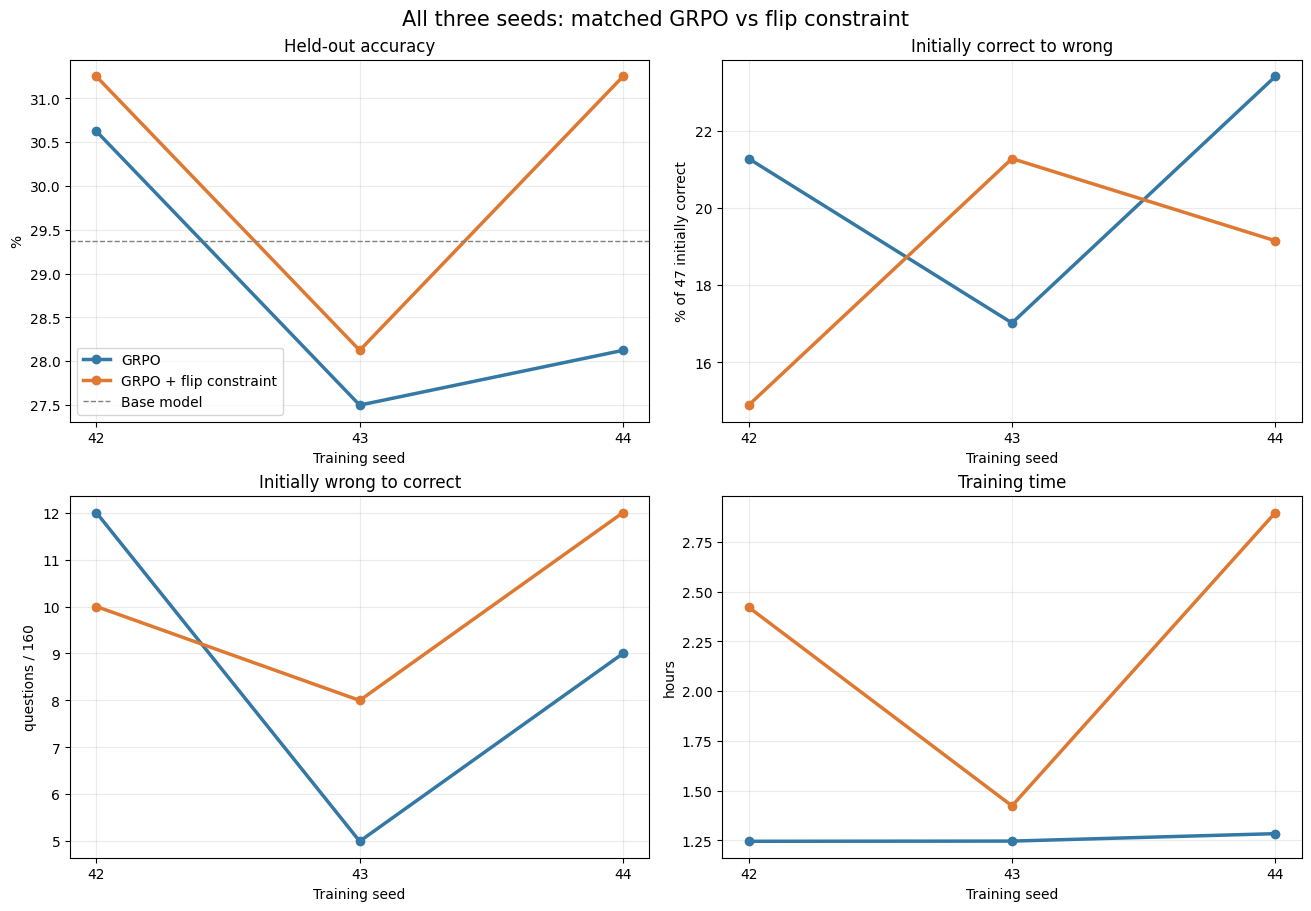

,seed,method,accuracy_pct,correct_to_wrong,wrong_to_correct,flip_pct,train_hours
1,42,grpo,30.63,10,12,21.28,1.25
2,42,flip_constrained_grpo,31.25,7,10,14.89,2.42
4,43,grpo,27.50,8,5,17.02,1.25
5,43,flip_constrained_grpo,28.12,10,8,21.28,1.42
7,44,grpo,28.12,11,9,23.40,1.28
8,44,flip_constrained_grpo,31.25,9,12,19.15,2.90


accuracy_pct       correct_to_wrong        \
                              mean   std             mean   std   
method                                                            
flip_constrained_grpo        30.21  1.80             8.67  1.53   
grpo                         28.75  1.65             9.67  1.53   

                      wrong_to_correct       train_hours        
                                  mean   std        mean   std  
method                                                          
flip_constrained_grpo            10.00  2.00        2.25  0.75  
grpo                              8.67  3.51        1.26  0.02

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'configs' / 'general_math_baseline.json').exists():
    root = root / 'pact_grpo_math'
run = root / 'outputs' / 'general_math_paper_baselines_1024_v1'
replication = pd.read_csv(run / 'seed_replication_comparison.csv')
methods = ['grpo', 'flip_constrained_grpo']
paired = replication[replication.method.isin(methods)].copy()
expected = {(seed, method) for seed in (42, 43, 44) for method in methods}
actual = set(zip(paired.seed, paired.method))
if actual != expected or len(paired) != len(expected):
    raise ValueError('Expected one GRPO and one constraint result for each seed 42, 43, 44')
paired['accuracy_pct'] = paired.test_macro_accuracy * 100
paired['flip_pct'] = paired.correct_to_wrong_rate * 100
paired['train_hours'] = paired.train_seconds / 3600
initial_accuracy = replication.loc[replication.method.eq('initial'), 'test_macro_accuracy'].iloc[0] * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
charts = [
    ('accuracy_pct', 'Held-out accuracy', '%'),
    ('flip_pct', 'Initially correct to wrong', '% of 47 initially correct'),
    ('wrong_to_correct', 'Initially wrong to correct', 'questions / 160'),
    ('train_hours', 'Training time', 'hours'),
]
colors = {'grpo': '#3478a5', 'flip_constrained_grpo': '#df7831'}
labels = {'grpo': 'GRPO', 'flip_constrained_grpo': 'GRPO + flip constraint'}
for ax, (metric, title, unit) in zip(axes.flat, charts):
    for method in methods:
        rows = paired[paired.method.eq(method)].sort_values('seed')
        ax.plot(rows.seed, rows[metric], marker='o', linewidth=2.5,
                color=colors[method], label=labels[method])
    if metric == 'accuracy_pct':
        ax.axhline(initial_accuracy, color='gray', linestyle='--', linewidth=1,
                   label='Base model')
    ax.set(title=title, xlabel='Training seed', ylabel=unit, xticks=[42, 43, 44])
    ax.grid(alpha=.25)
axes[0, 0].legend()
fig.suptitle('All three seeds: matched GRPO vs flip constraint', fontsize=15)
plt.show()
display(paired[['seed', 'method', 'accuracy_pct', 'correct_to_wrong',
                'wrong_to_correct', 'flip_pct', 'train_hours']].round(2))
display(paired.groupby('method')[['accuracy_pct', 'correct_to_wrong',
                                   'wrong_to_correct', 'train_hours']].agg(['mean', 'std']).round(2))


## Góc nhìn bổ sung: gộp seed 42 và 44

**Đây là biểu đồ chọn sau khi đã thấy kết quả**, không dùng để kết luận method ổn định. Seed 43 vẫn nằm trong kết quả chính ở trên. Hai seed dùng lại cùng 160 câu test, nên 320 là số lượt đánh giá, không phải 320 câu độc lập.


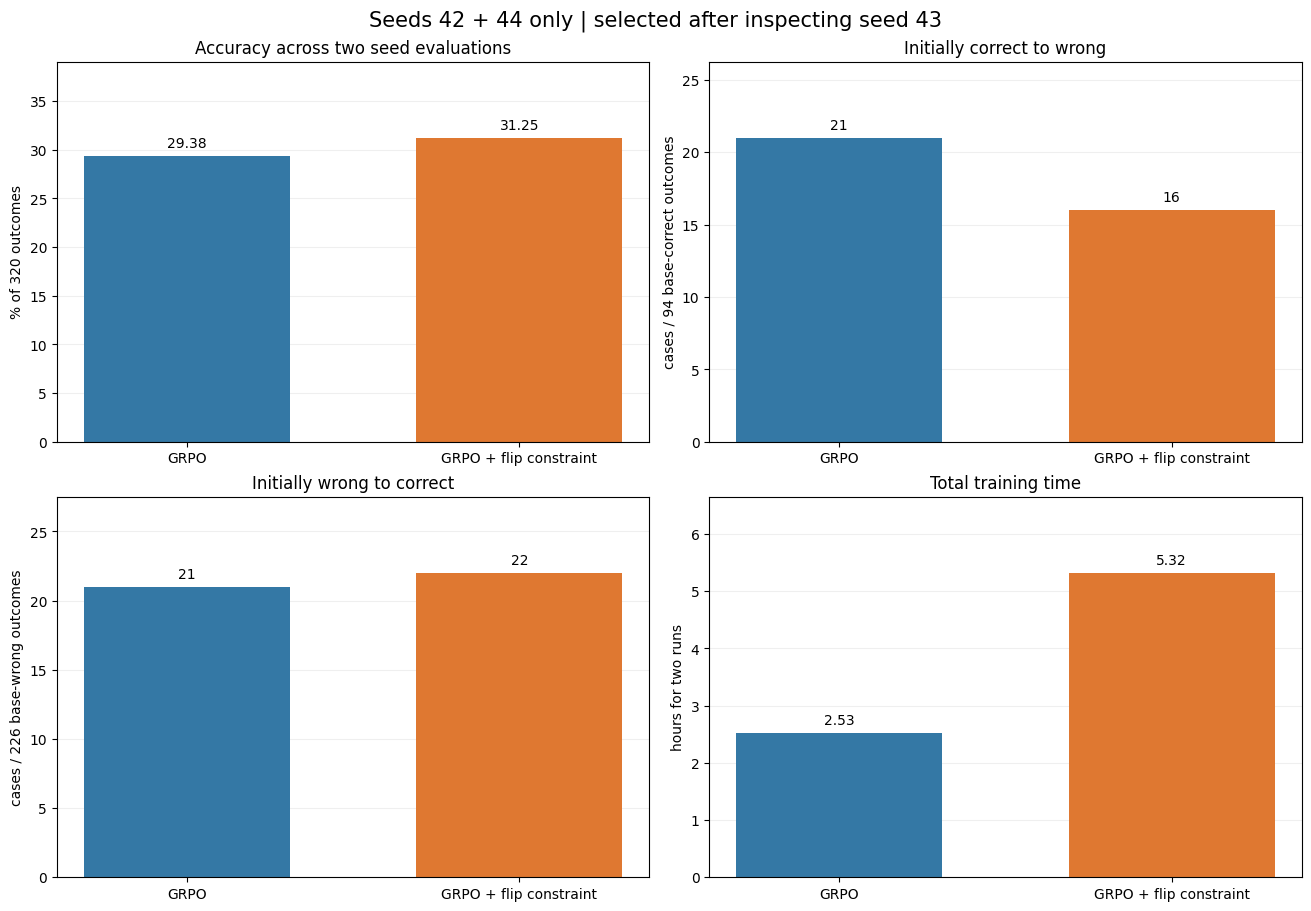

,correct,accuracy_pct,flips,flip_pct,recovered,train_hours
method,,,,,,
grpo,94,29.38,21,22.34,21,2.53
flip_constrained_grpo,100,31.25,16,17.02,22,5.32


In [9]:
# Supplementary selected-seed view; do not use as the primary aggregate.
selected = paired[paired.seed.isin([42, 44])].copy()
if len(selected) != 4:
    raise ValueError('Expected both methods at seed 42 and seed 44')
summary = selected.groupby('method', sort=False).agg(
    correct=('test_macro_accuracy', lambda values: round(values.sum() * 160)),
    flips=('correct_to_wrong', 'sum'),
    recovered=('wrong_to_correct', 'sum'),
    train_hours=('train_hours', 'sum'),
).reindex(methods)
# The same 160 test questions appear under both seeds: 320 outcomes, not 320 unique questions.
summary['accuracy_pct'] = summary.correct / 320 * 100
summary['flip_pct'] = summary.flips / (47 * 2) * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
metrics = [
    ('accuracy_pct', 'Accuracy across two seed evaluations', '% of 320 outcomes'),
    ('flips', 'Initially correct to wrong', 'cases / 94 base-correct outcomes'),
    ('recovered', 'Initially wrong to correct', 'cases / 226 base-wrong outcomes'),
    ('train_hours', 'Total training time', 'hours for two runs'),
]
for ax, (metric, title, unit) in zip(axes.flat, metrics):
    bars = ax.bar([labels[method] for method in methods], summary[metric],
                  color=[colors[method] for method in methods], width=.62)
    ax.bar_label(bars, fmt='%.2f' if metric in ('accuracy_pct', 'train_hours') else '%d', padding=4)
    ax.set(title=title, ylabel=unit)
    ax.grid(axis='y', alpha=.2)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(summary[metric]) * 1.25)
fig.suptitle('Seeds 42 + 44 only | selected after inspecting seed 43', fontsize=15)
plt.show()
display(summary[['correct', 'accuracy_pct', 'flips', 'flip_pct',
                 'recovered', 'train_hours']].round(2))


## Feedback v2 — seeds 43 and 45
Loader precision now matches QLoRA training. Baseline and correct anchors are re-evaluated;
feedback is applied before the current update using latest outcomes of distinct anchor IDs.
These results are separate from v1: do not pool old and new baselines or discard old seed 43.
Run `run_replication.py` first. A completed seed-43 pair can be shown before seed 45 finishes.
The question set is unchanged and already inspected; this is a method revision, not a fresh test set.

In [ ]:
revision_config = json.loads((root / 'configs/general_math_feedback_v2.json').read_text(encoding='utf-8'))
revision_output = root / 'outputs' / revision_config['run_name']
revision_csv = revision_output / 'comparison.csv'
revision_results = pd.read_csv(revision_csv) if revision_csv.exists() else pd.DataFrame()
if revision_results.empty:
    print('No v2 evaluation yet. Run run_replication.py; historical plots above are v1.')
else:
    from IPython.display import display
    display(revision_results[['seed','method','test_macro_accuracy','initially_correct_test',
        'correct_to_wrong','correct_to_wrong_rate','wrong_to_correct',
        'rollout_tokens','retention_eval_tokens','initial_anchor_audit_tokens',
        'optimizer_updates','train_seconds']])
    revision_seeds = sorted(revision_results.seed.unique())
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    revision_methods = ['grpo','flip_constrained_grpo']
    revision_colors = ['#4878a8','#7a54a8']
    positions = np.arange(len(revision_seeds))
    for i, method in enumerate(revision_methods):
        data = revision_results[revision_results.method == method].set_index('seed').reindex(revision_seeds)
        for ax, col, scale in [(axes[0,0],'test_macro_accuracy',100),
                               (axes[0,1],'correct_to_wrong_rate',100),
                               (axes[1,0],'wrong_to_correct',1),
                               (axes[1,1],'train_seconds',1/3600)]:
            bars = ax.bar(positions + (i-.5)*.34, data[col]*scale, .34,
                          label='GRPO' if i==0 else 'GRPO + constraint v2', color=revision_colors[i])
            ax.bar_label(bars, fmt='%.2f', padding=3)
    baseline = revision_results[revision_results.method == 'initial'].iloc[0]
    axes[0,0].axhline(baseline.test_macro_accuracy*100, color='gray', linestyle='--', label='Aligned initial')
    axes[0,0].set(title='Accuracy on full held-out test', ylabel='Percent', ylim=(0,100))
    axes[0,1].set(title=f'Correct to wrong: denominator {int(baseline.initially_correct_test)} base-correct questions',
                  ylabel='Percent', ylim=(0,100))
    axes[1,0].set(title='Wrong to correct', ylabel='Questions')
    axes[1,1].set(title='Training time including initial anchor audit', ylabel='Hours')
    for ax in axes.flat:
        ax.set_xticks(positions, [f'Seed {s}' for s in revision_seeds])
        ax.legend(fontsize=8)
    fig.suptitle('Feedback v2: all completed requested seeds; lower flip rate must be read with accuracy')
    plt.show()

In [ ]:
if not revision_results.empty:
    revision_means = revision_results.groupby('method').mean(numeric_only=True)
    methods_v2 = ['initial','grpo','flip_constrained_grpo']
    topics_v2 = revision_config['topics']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    positions = np.arange(len(topics_v2))
    for i, method in enumerate(methods_v2):
        row = revision_means.loc[method]
        xs = positions + (i-1)*.25
        axes[0].bar(xs, [row[f'test_{topic}']*100 for topic in topics_v2], .25, label=method)
        axes[1].bar(xs, [row[f'test_flip_rate_{topic}']*100 for topic in topics_v2], .25, label=method)
    axes[0].set(title='Accuracy by topic: mean across completed v2 seeds', ylabel='Percent', ylim=(0,100))
    axes[1].set(title='Conditional correct-to-wrong rate by topic', ylabel='Percent', ylim=(0,100))
    for ax in axes:
        ax.set_xticks(positions,[topic.replace('_',' ') for topic in topics_v2], rotation=15)
        ax.legend(fontsize=8)
    print('Base-correct denominators by topic:',
          {topic: int(revision_means.loc['initial',f'initially_correct_test_{topic}']) for topic in topics_v2})
    print('Same held-out questions are reused across seeds; these are not independent new questions.')
    plt.show()

In [ ]:
fig, axes = plt.subplots(1, len(revision_config['training_seeds']), figsize=(14,4), constrained_layout=True, squeeze=False)
for ax, seed in zip(axes.flat, revision_config['training_seeds']):
    path = revision_output / f'seed_{seed}' / 'flip_constrained_grpo' / 'train_metrics.jsonl'
    if not path.exists():
        ax.set_title(f'Seed {seed}: not started')
        continue
    feedback_log = pd.read_json(path, lines=True)
    for topic in revision_config['topics']:
        selected = feedback_log[feedback_log.retention_topic == topic]
        ax.plot(selected.step, selected.retention_weight_used, 'o-', label=topic.replace('_',' '))
    ax.set(title=f'Seed {seed}: protection weight actually applied',
           xlabel='GRPO step', ylabel='Lambda', ylim=(0,1.05))
    ax.legend(fontsize=7)
plt.show()